In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("Cleaned_Car_Price_Data.csv")

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        724 non-null    object
 1   company     724 non-null    object
 2   year        724 non-null    int64 
 3   Price       724 non-null    int64 
 4   kms_driven  724 non-null    int64 
 5   fuel_type   724 non-null    object
dtypes: int64(3), object(3)
memory usage: 34.1+ KB


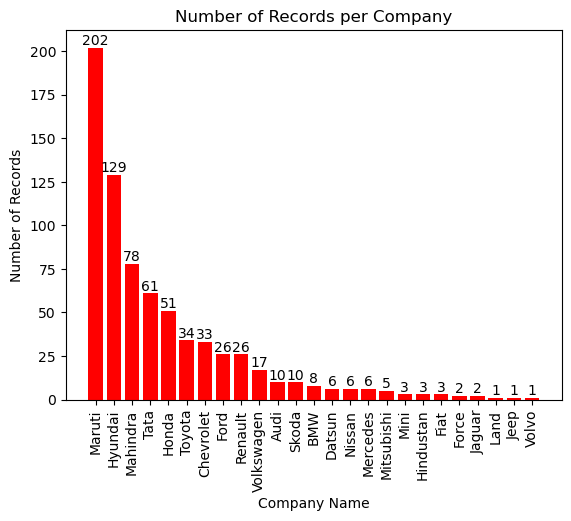

In [32]:
# Lets find number of vehicles by company
company_counts  = df['company'].value_counts()
company_counts
# company_counts.plot(kind='bar')
fig, ax = plt.subplots()
# # # ax
# # # # Add labels and title
plt.xlabel('Company Name')
plt.ylabel('Number of Records')
plt.title('Number of Records per Company')

# # # Plot bar chart
bars = ax.bar(company_counts.index, company_counts.values, color='red')
ax.bar_label(bars)
plt.xticks(rotation=90)
# company_counts.values

# # # Display chart
plt.show()

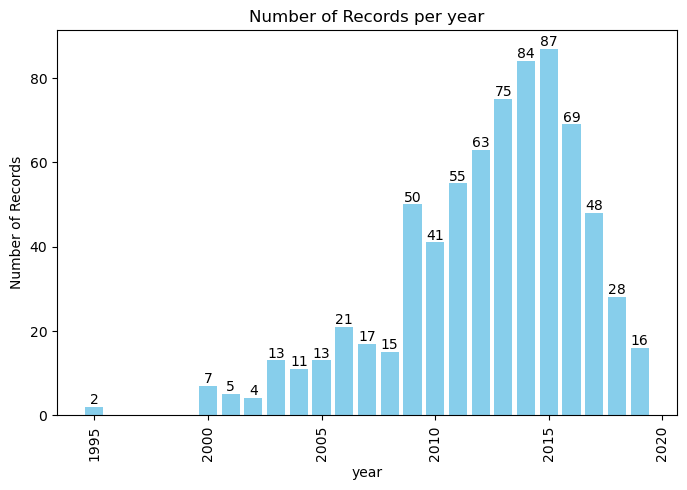

In [34]:
# number of vehicles per year
# Lets find number of vehicles by company

year_counts  = df['year'].value_counts().sort_index()
# 
# year_counts# # company_counts
# company_counts.plot(kind='bar')
fig, ax = plt.subplots(figsize= (8,5))
# # ax
# # # Add labels and title
plt.xlabel('year')
plt.ylabel('Number of Records')
plt.title('Number of Records per year')

# # Plot bar chart
bars = ax.bar(year_counts.index, year_counts.values, color='skyblue')
ax.bar_label(bars)
plt.xticks(rotation=90)


# # Display chart
plt.show()

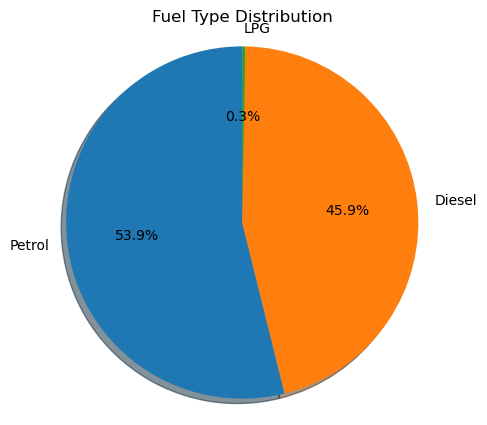

In [36]:
# vehicles by fuel type
fuel_counts  = df['fuel_type'].value_counts()
# fuel_counts
plt.figure(figsize = (5,5))
# colors = ['red', 'blue', 'green'] 
plt.pie(
    fuel_counts.values,
    labels = fuel_counts.index,
    autopct = '%1.1f%%',
    startangle = 90,
    shadow = True,
    # colors = colors,
# explode=[0.05]*len(fuel_counts))
)
plt.axis('equal')
plt.title("Fuel Type Distribution")
plt.show()

In [38]:
table = pd.crosstab(df['company'], df['fuel_type'], margins=True, margins_name='Total')
print(table)

fuel_type   Diesel  LPG  Petrol  Total
company                               
Audi             7    0       3     10
BMW              5    0       3      8
Chevrolet       20    0      13     33
Datsun           0    0       6      6
Fiat             1    0       2      3
Force            2    0       0      2
Ford            16    0      10     26
Hindustan        2    0       1      3
Honda           12    0      39     51
Hyundai         25    0     104    129
Jaguar           1    0       1      2
Jeep             1    0       0      1
Land             1    0       0      1
Mahindra        75    0       3     78
Maruti          55    2     145    202
Mercedes         2    0       4      6
Mini             0    0       3      3
Mitsubishi       3    0       2      5
Nissan           3    0       3      6
Renault         18    0       8     26
Skoda            7    0       3     10
Tata            46    0      15     61
Toyota          18    0      16     34
Volkswagen      11    0  

In [40]:
# # Define bins (price ranges)
bins = [0, 500000, 1000000, 1500000, 2000000, 3000000, 5000000, 10000000]

# Define corresponding group names (labels)
labels = [
    '0 - 5 Lakh',
    '5 - 10 Lakh',
    '10 - 15 Lakh',
    '15 - 20 Lakh',
    '20 - 30 Lakh',
    '30 - 50 Lakh',
    '50 Lakh - 1 Cr'
]
# Add a new column 'group' in your DataFrame
df['group'] = pd.cut(df['Price'], bins=bins, labels=labels, right=True)

In [42]:
pd.crosstab(df['group'], df['company'])

company,Audi,BMW,Chevrolet,Datsun,Fiat,Force,Ford,Hindustan,Honda,Hyundai,...,Mercedes,Mini,Mitsubishi,Nissan,Renault,Skoda,Tata,Toyota,Volkswagen,Volvo
group,,,,,,,,,,,,,,,,,,,,,
0 - 5 Lakh,1,0,33,6,3,0,16,2,41,108,...,1,0,1,5,19,9,58,21,13,0
5 - 10 Lakh,2,3,0,0,0,2,9,1,10,20,...,1,0,0,0,7,1,3,10,3,0
10 - 15 Lakh,2,4,0,0,0,0,0,0,0,1,...,3,0,2,1,0,0,0,2,1,0
15 - 20 Lakh,3,1,0,0,0,0,0,0,0,0,...,1,3,2,0,0,0,0,1,0,1
20 - 30 Lakh,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30 - 50 Lakh,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50 Lakh - 1 Cr,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
df['group'].value_counts()

group
0 - 5 Lakh        561
5 - 10 Lakh       125
10 - 15 Lakh       19
15 - 20 Lakh       12
20 - 30 Lakh        5
30 - 50 Lakh        1
50 Lakh - 1 Cr      1
Name: count, dtype: int64

C:\Users\91937\AppData\Local\Temp\ipykernel_20296\624815975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='company', y='Price', palette='Set2')


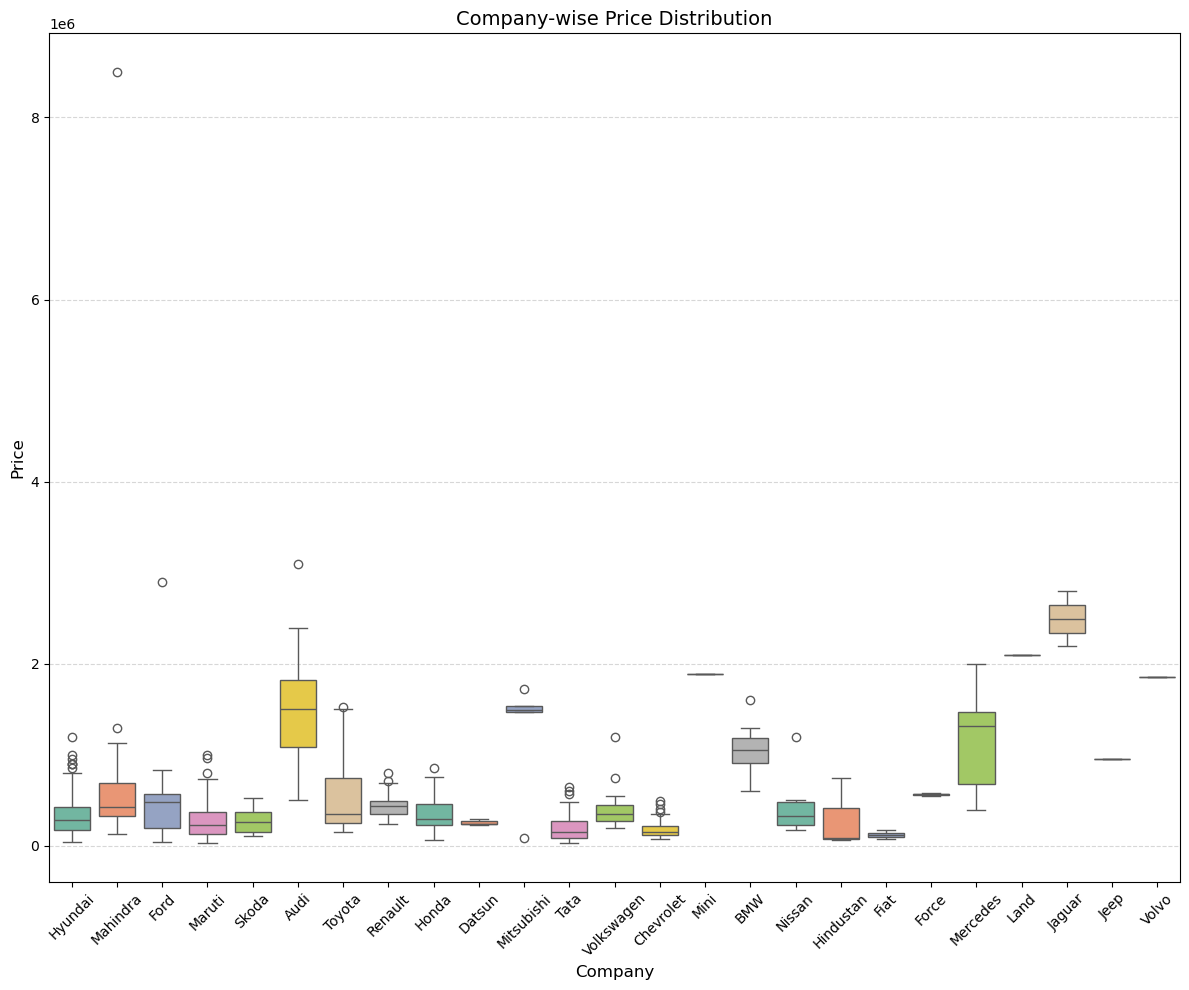

In [46]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df, x='company', y='Price', palette='Set2')

plt.title('Company-wise Price Distribution', fontsize=14)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [47]:
# df.info()

In [50]:
# df['group'].value_counts()

In [52]:
# Outlier Detection
# IQR => Inter Quartile Range

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

# IQR
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_clean = df[(df['Price'] >= lower_bound)&(df['Price'] <= upper_bound)]

In [54]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 679 entries, 0 to 723
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   name        679 non-null    object  
 1   company     679 non-null    object  
 2   year        679 non-null    int64   
 3   Price       679 non-null    int64   
 4   kms_driven  679 non-null    int64   
 5   fuel_type   679 non-null    object  
 6   group       679 non-null    category
dtypes: category(1), int64(3), object(3)
memory usage: 38.1+ KB


In [56]:
# plt.figure(figsize=(12,10))
# sns.boxplot(data=df_clean, x='company', y='Price', palette='Set2')

# plt.title('Company-wise Price Distribution', fontsize=14)
# plt.xlabel('Company', fontsize=12)
# plt.ylabel('Price', fontsize=12)

# plt.xticks(rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()

# plt.show()

In [58]:
df_clean.drop(columns = ['group'] , inplace = True)

C:\Users\91937\AppData\Local\Temp\ipykernel_20296\2141619439.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns = ['group'] , inplace = True)


In [60]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 679 entries, 0 to 723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        679 non-null    object
 1   company     679 non-null    object
 2   year        679 non-null    int64 
 3   Price       679 non-null    int64 
 4   kms_driven  679 non-null    int64 
 5   fuel_type   679 non-null    object
dtypes: int64(3), object(3)
memory usage: 37.1+ KB


In [62]:
df_clean.to_csv("final_cleaned_dataset.csv", index = False)

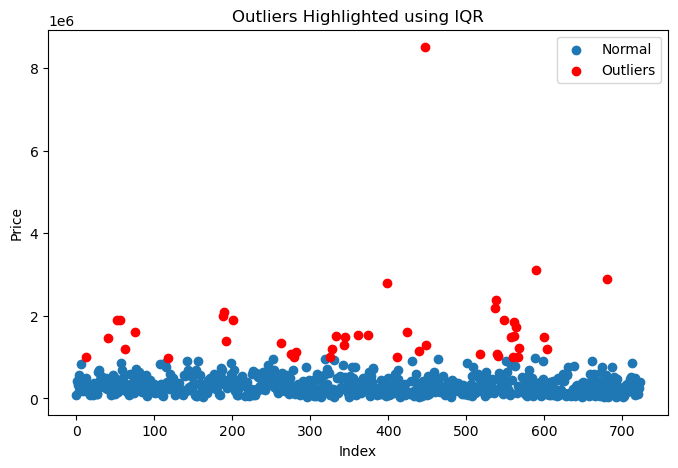

In [64]:
import matplotlib.pyplot as plt

# Step 1: Calculate IQR (your code)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 2: Separate normal & outliers
normal_data = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

# Step 3: Scatter Plot
plt.figure(figsize=(8,5))

# Normal points
plt.scatter(normal_data.index, normal_data['Price'], label='Normal')

# Outliers (highlight in red)
plt.scatter(outliers.index, outliers['Price'], color='red', label='Outliers')

# Labels
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Outliers Highlighted using IQR")
plt.legend()

plt.show()

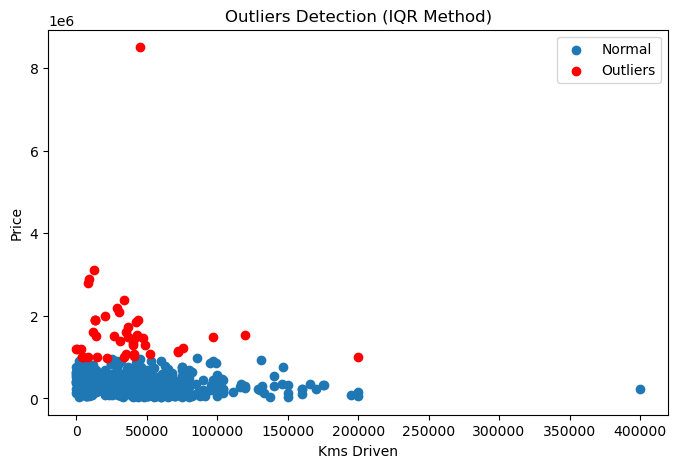

In [66]:
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: IQR Calculation
# -------------------------------
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# -------------------------------
# Step 2: Separate Data
# -------------------------------
normal_data = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

# -------------------------------
# Step 3: Scatter Plot
# -------------------------------
plt.figure(figsize=(8,5))

# Normal data
plt.scatter(normal_data['kms_driven'], normal_data['Price'], label='Normal')

# Outliers (highlighted)
plt.scatter(outliers['kms_driven'], outliers['Price'], color='red', label='Outliers')

# Labels & Title
plt.xlabel("Kms Driven")
plt.ylabel("Price")
plt.title("Outliers Detection (IQR Method)")
plt.legend()

plt.show()

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   name        724 non-null    object  
 1   company     724 non-null    object  
 2   year        724 non-null    int64   
 3   Price       724 non-null    int64   
 4   kms_driven  724 non-null    int64   
 5   fuel_type   724 non-null    object  
 6   group       724 non-null    category
dtypes: category(1), int64(3), object(3)
memory usage: 35.1+ KB
